### Домашнее задание по визуализации

В домашнем задании будем работать с данными фильмов на IMDB. 

Для начала считаем данные и проигнорируем все строки, которые не распарсились (для простоты).

In [234]:
# pyrefly: ignore-errors

import pandas as pd
df = pd.read_csv('imdb.csv', on_bad_lines='skip')

In [235]:
df.columns

Index(['fn', 'tid', 'title', 'wordsInTitle', 'url', 'imdbRating',
       'ratingCount', 'duration', 'year', 'type', 'nrOfWins',
       'nrOfNominations', 'nrOfPhotos', 'nrOfNewsArticles', 'nrOfUserReviews',
       'nrOfGenre', 'Action', 'Adult', 'Adventure', 'Animation', 'Biography',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'FilmNoir', 'GameShow', 'History', 'Horror', 'Music', 'Musical',
       'Mystery', 'News', 'RealityTV', 'Romance', 'SciFi', 'Short', 'Sport',
       'TalkShow', 'Thriller', 'War', 'Western'],
      dtype='object')

__Задача 1:__ С каким параметром больше всего коррелирует число побед? 
Ответ на задачу - название колонки в dataframe, с которой больше всего коррелирует `nrOfWins`.

In [236]:
df.corr(numeric_only=True)['nrOfWins'].sort_values(ascending=False).head()

nrOfWins            1.000000
nrOfNominations     0.809314
ratingCount         0.414537
nrOfUserReviews     0.382080
nrOfNewsArticles    0.362361
Name: nrOfWins, dtype: float64

__Задача 2:__ Посмотрите, как изменялась средняя оценка фильмов (рейтинг IMDB) с течением времени? В какое десятилетие была самая высокая средняя оценка. 

Ответ - tuple, где на первом месте тип тренда (слово 'ascending' или 'descending'), на втором - десятилие, например, если самые "хорошие" фильмы были в период 1950 - 1959, то 1950.

In [237]:
import matplotlib.pyplot as plt

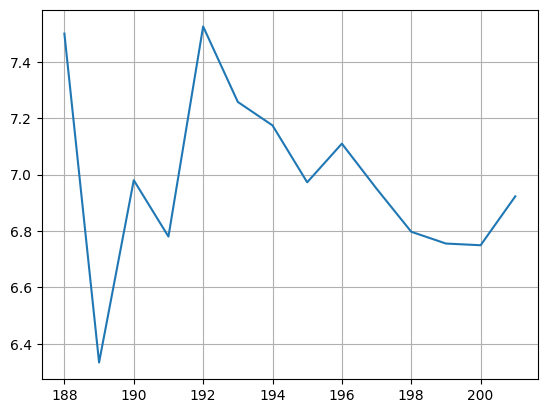

In [238]:
df['decade'] = df['year'] // 10
plt.figure()
plt.plot(df.groupby('decade')['imdbRating'].mean())
plt.grid()
plt.show()

__Задача 3:__ Исследумем распределение оценок фильмов по жанрам (если фильм принадлежит нескольким жанрам, то будем учитывать его в каждом из них). Для простоты будем смотреть на топ-10 самых популярных жанров (по числу фильмов с этим жанром). В ответе укажите 2 жанра: жанр с самой высокой средней оценкой (по медиане) и с самой большой дисперсией (по IQR). Если у нескольких жанров одинаковый показатель, то стоит указать первый по алфавиту. 

Ответ - tuple с двумя жанрами

In [239]:
import scipy.stats as sps

In [240]:
genres_cols = df.columns[16:-1]  # w/o decade
top10_genres = df[genres_cols].sum().sort_values(ascending=False).head(10)
top10_genres

Drama          5982
Comedy         5164
Action         2237
Crime          1978
Romance        1806
Adventure      1768
Thriller       1295
Documentary    1147
Family         1044
Horror         1013
dtype: int64

In [241]:
df_top10_genres = df[df[top10_genres.index].sum(1) > 0]
df_top10_genres_rating = df_top10_genres[list(top10_genres.index) + ['imdbRating']]

In [242]:
df_top10_genres_rating_report = pd.DataFrame(columns=top10_genres.index, index=['median', 'IQR'])
for col in df_top10_genres_rating_report.columns:
    ratings = df_top10_genres_rating.loc[df_top10_genres_rating[col] == 1, 'imdbRating']

    df_top10_genres_rating_report.loc['median', col] = ratings.median()
    df_top10_genres_rating_report.loc['IQR', col] = sps.iqr(ratings, nan_policy='omit')

In [243]:
df_top10_genres_rating_report.T.sort_values('median', ascending=False)

,median,IQR
Documentary,7.3,1.075
Drama,7.2,1.1
Comedy,7.0,1.4
Crime,7.0,1.2
Romance,7.0,1.3
Adventure,6.9,1.3
Family,6.9,1.5
Action,6.7,1.4
Thriller,6.7,1.3
Horror,6.2,1.5


In [244]:
df_top10_genres_rating_report.T.sort_values('IQR', ascending=False)

,median,IQR
Family,6.9,1.5
Horror,6.2,1.5
Action,6.7,1.4
Comedy,7.0,1.4
Romance,7.0,1.3
Adventure,6.9,1.3
Thriller,6.7,1.3
Crime,7.0,1.2
Drama,7.2,1.1
Documentary,7.3,1.075


__Задача 4:__ Посмотрим на распределение фильмов по числу слов в названии. Какой график вы бы для этого построили и какова мода (самое частотое значение) этого распределения?

Ответ - число слов, которое встречается в большем количестве фильмов.

<Axes: >

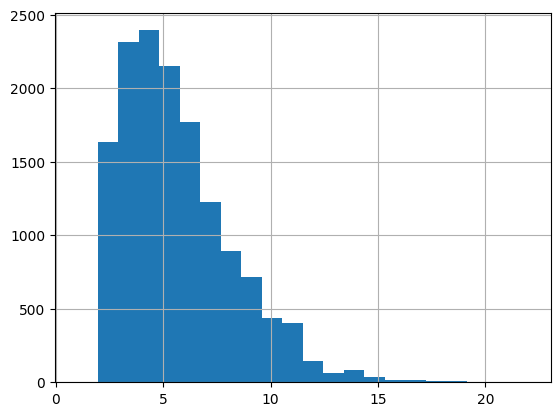

In [245]:
title_word_length = df['title'].apply(lambda x: len(x.replace('(', '').replace(')', '').split()))
title_word_length.hist(bins=title_word_length.unique().max())

In [246]:
print(f"Mode: {title_word_length.mode().item()}")

Mode: 4


__Вопрос 5:__ Посмотрим на то, как менялась со временем продолжительность фильмов? Постройте график и ответьте на вопрос, в каком десятилетии доля коротких фильмов (короче часа) была выше всего? Рассматриваем период >= 1920 года.

Ответ - десятилетие, например, если больше всего коротких фильмов было в период 1950 - 1959, то 1950.

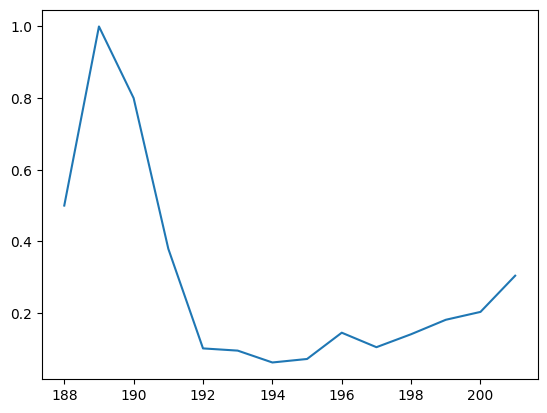

In [247]:
df['is_short'] = (df['duration'] < 3600)
total_per_decade = df.groupby(['decade'])['title'].count()
short_per_decade = df[df['duration'] < 3600].groupby(['decade'])['title'].count()

short_frac_per_decade = short_per_decade / total_per_decade

plt.figure()
plt.plot(short_frac_per_decade)
plt.show()

__Вопрос 6:__ И последний вопрос: фильмам какого жанра пользователи оставляют больше всего рецензий? Подумайте о  том, по какой метрике лучше всего смотреть. В ответе укажите жанр.

In [248]:
df_top10_genres_reviews = df_top10_genres[list(top10_genres.index) + ['nrOfUserReviews']]

In [249]:
top10_genres

Drama          5982
Comedy         5164
Action         2237
Crime          1978
Romance        1806
Adventure      1768
Thriller       1295
Documentary    1147
Family         1044
Horror         1013
dtype: int64

In [250]:
df_top10_genres_reviews_report = pd.DataFrame(columns=top10_genres.index, index=['median', 'mean'])
for col in df_top10_genres_reviews_report.columns:
    reviews = df_top10_genres_reviews.loc[df_top10_genres_reviews[col] == 1, 'nrOfUserReviews']

    df_top10_genres_reviews_report.loc['median', col] = reviews.median()
    df_top10_genres_reviews_report.loc['mean', col] = reviews.mean()

In [261]:
df_top10_genres_reviews_report.T.sort_values(by='median', ascending=False)

,median,mean
Thriller,120.0,224.675676
Horror,85.0,169.312932
Action,59.0,188.304426
Crime,58.0,136.391304
Adventure,56.0,189.973416
Romance,51.0,111.594131
Drama,49.0,118.650953
Comedy,26.0,73.484508
Family,24.0,73.344828
Documentary,1.0,15.88143


In [262]:
df_top10_genres_reviews_report.T.sort_values(by='mean', ascending=False)

,median,mean
Thriller,120.0,224.675676
Adventure,56.0,189.973416
Action,59.0,188.304426
Horror,85.0,169.312932
Crime,58.0,136.391304
Drama,49.0,118.650953
Romance,51.0,111.594131
Comedy,26.0,73.484508
Family,24.0,73.344828
Documentary,1.0,15.88143
